C:\Users\lenovo\AppData\Local\Temp\ipykernel_37720\346490832.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[comp_cols] = df_clean[comp_cols].fillna(0).apply(pd.to_numeric, errors='coerce').fillna(0)


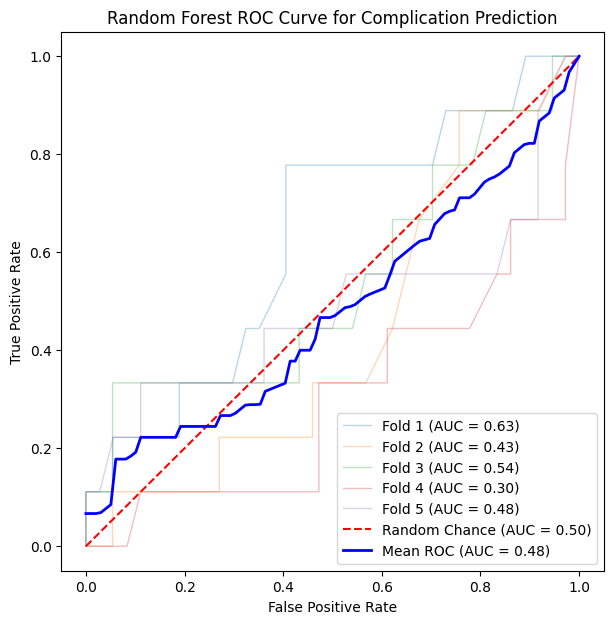

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc

# 1. 合并四个数据集
file_names = [
    r"C:\Users\lenovo\Desktop\接单\机器学习模型\腹腔镜全胃切除数据.xlsx",
    r"C:\Users\lenovo\Desktop\接单\机器学习模型\腹腔镜远端胃切除数据.xlsx",
    r"C:\Users\lenovo\Desktop\接单\机器学习模型\机器人全胃切除数据.xlsx",
    r"C:\Users\lenovo\Desktop\接单\机器学习模型\机器人远端胃切除数据.xlsx"
]
df = pd.concat([pd.read_excel(f) for f in file_names], ignore_index=True)

# 2. 特征工程
# 选择论文提到的 6 个关键变量
features = ['Operation1开腹2腔镜3机器人', '手术操作时间min', '术中出血量ml', 'Age', 'BMI', 'Gender1男2女']
df_clean = df.dropna(subset=features)

# 构建目标变量（是否有任何术后并发症）
comp_cols = ['腹腔感染1是0否', '腹腔出血1是0否', '切口感染1是0否', '肺部感染1是0否', '肠梗阻1是0否', '胃潴留1是0否']
df_clean[comp_cols] = df_clean[comp_cols].fillna(0).apply(pd.to_numeric, errors='coerce').fillna(0)
y = (df_clean[comp_cols].sum(axis=1) > 0).astype(int)

# 处理特征
X = df_clean[features].copy()
X['Operation1开腹2腔镜3机器人'] = X['Operation1开腹2腔镜3机器人'].map({2: 0, 3: 1}) # 2:LG, 3:RG
X['Gender1男2女'] = X['Gender1男2女'].map({1: 0, 2: 1}) # 1:男, 2:女

# 3. 5折交叉验证与绘图
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
classifier = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

tprs, aucs = [], []
mean_fpr = np.linspace(0, 1, 100)
plt.figure(figsize=(7, 7))

for i, (train, test) in enumerate(cv.split(X, y)):
    classifier.fit(X.iloc[train], y.iloc[train])
    fpr, tpr, _ = roc_curve(y.iloc[test], classifier.predict_proba(X.iloc[test])[:, 1])
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    aucs.append(auc(fpr, tpr))
    plt.plot(fpr, tpr, lw=1, alpha=0.3, label=f'Fold {i+1} (AUC = {aucs[-1]:.2f})')

# 绘制均值和随机参考线
plt.plot([0, 1], [0, 1], 'r--', label='Random Chance (AUC = 0.50)')
mean_tpr = np.mean(tprs, axis=0)
plt.plot(mean_fpr, mean_tpr, color='b', label=f'Mean ROC (AUC = {np.mean(aucs):.2f})', lw=2)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve for Complication Prediction')
plt.legend(loc="lower right")
plt.show()

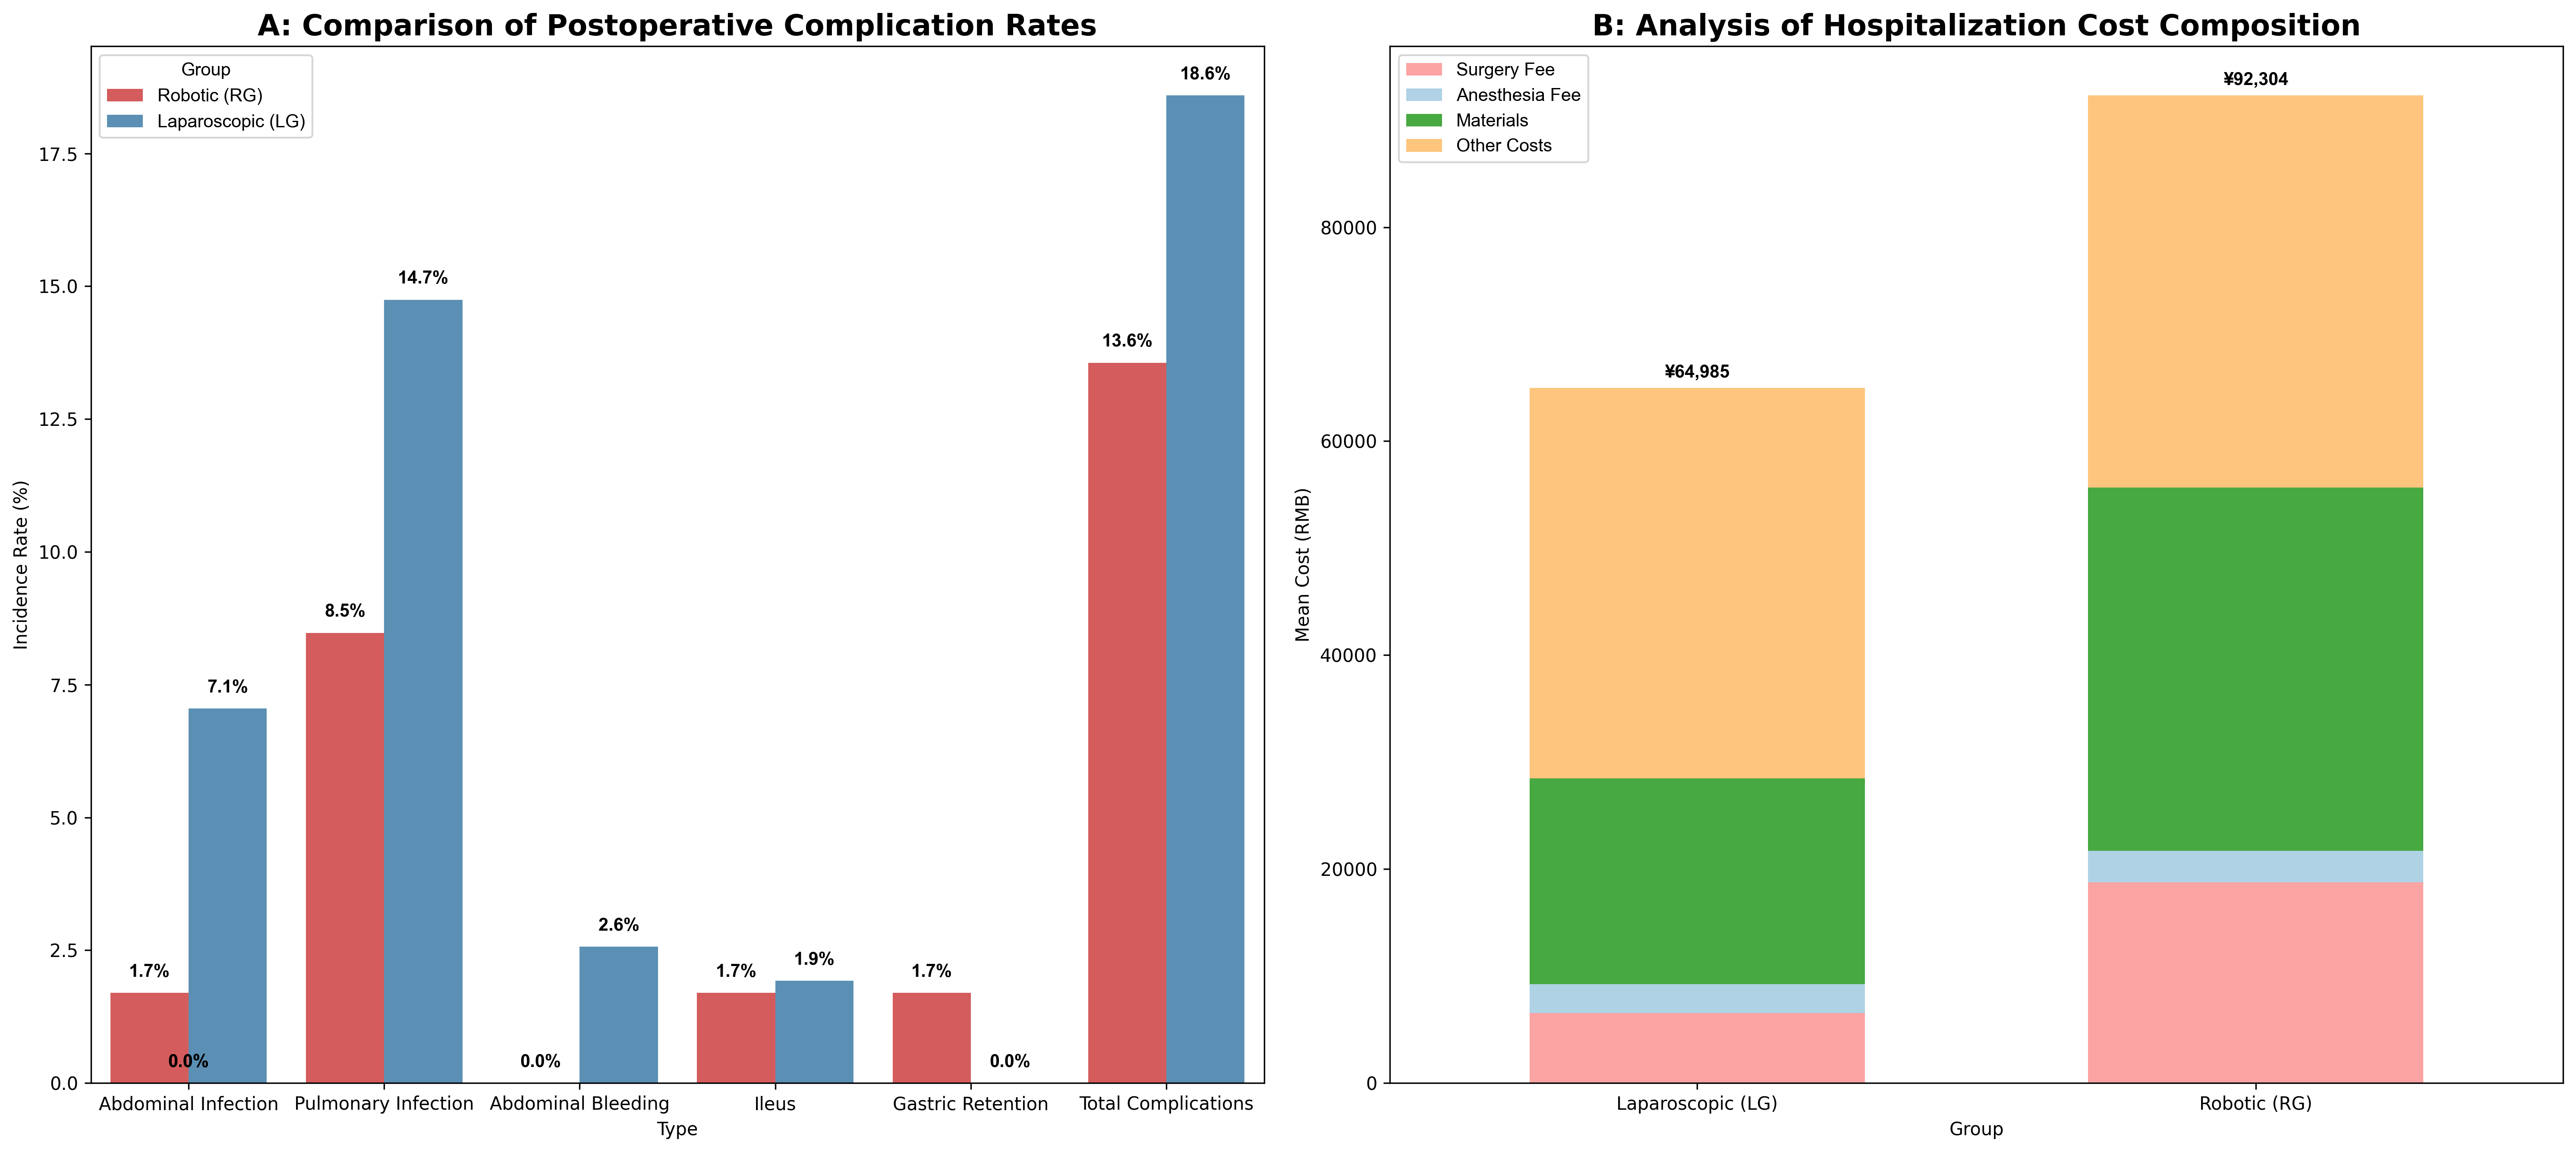

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 加载并合并数据集
file_names = [
    r"C:\Users\lenovo\Desktop\接单\机器学习模型\腹腔镜全胃切除数据.xlsx",
    r"C:\Users\lenovo\Desktop\接单\机器学习模型\腹腔镜远端胃切除数据.xlsx",
    r"C:\Users\lenovo\Desktop\接单\机器学习模型\机器人全胃切除数据.xlsx",
    r"C:\Users\lenovo\Desktop\接单\机器学习模型\机器人远端胃切除数据.xlsx"
]
df = pd.concat([pd.read_excel(f) for f in file_names], ignore_index=True)
df['Group'] = df['Operation1开腹2腔镜3机器人'].map({3: 'Robotic (RG)', 2: 'Laparoscopic (LG)'})

# 2. A图：并发症数据处理
comp_map = {
    '腹腔感染1是0否': 'Abdominal Infection',
    '肺部感染1是0否': 'Pulmonary Infection',
    '腹腔出血1是0否': 'Abdominal Bleeding',
    '肠梗阻1是0否': 'Ileus',
    '胃潴留1是0否': 'Gastric Retention'
}
for col in comp_map.keys():
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# 计算总并发症 (Any_Comp)
def check_other(val):
    keywords = ['瘘', '肺炎', '感染', '梗阻', '胃管', '反流', '炎', '液化']
    val = str(val).lower()
    return 1 if any(k in val for k in keywords) and val not in ['0', 'nan', '无'] else 0

df['Other_Binary'] = df['其他并发症：吻合口瘘、十二指肠残端瘘'].apply(check_other)
df['Any_Comp'] = ((df[list(comp_map.keys())].sum(axis=1) > 0) | (df['Other_Binary'] == 1)).astype(int)

# 汇总各组发生率
comp_plot_data = []
for group in ['Robotic (RG)', 'Laparoscopic (LG)']:
    sub = df[df['Group'] == group]
    for raw, name in comp_map.items():
        comp_plot_data.append({'Type': name, 'Group': group, 'Rate': sub[raw].mean() * 100})
    comp_plot_data.append({'Type': 'Total Complications', 'Group': group, 'Rate': sub['Any_Comp'].mean() * 100})

# 3. B图：成本数据处理
cost_map = {'手术费': 'Surgery Fee', '麻醉费': 'Anesthesia Fee', '治疗用一次性医用材料费': 'Materials'}
df['Total_Cost'] = pd.to_numeric(df['总费用'], errors='coerce')
cost_summary = df.groupby('Group').agg({**{k: 'mean' for k in cost_map.keys()}, 'Total_Cost': 'mean'})
cost_summary['Other Costs'] = cost_summary['Total_Cost'] - cost_summary[list(cost_map.keys())].sum(axis=1)
cost_summary = cost_summary.drop(columns='Total_Cost').rename(columns=cost_map)

# 4. 开始绘图 (ABCD 布局风格)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9), dpi=300)
plt.rcParams['font.family'] = 'Arial'

# A图：发生率比较
palette = {'Robotic (RG)': '#E31A1C', 'Laparoscopic (LG)': '#1F78B4'}
sns.barplot(data=pd.DataFrame(comp_plot_data), x='Type', y='Rate', hue='Group', ax=ax1, palette=palette, alpha=0.8)
ax1.set_title('A: Comparison of Postoperative Complication Rates', fontsize=16, fontweight='bold')
ax1.set_ylabel('Incidence Rate (%)')
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', xytext=(0, 9), textcoords='offset points', fontweight='bold')

# B图：成本构成堆叠图
cost_summary.plot(kind='bar', stacked=True, ax=ax2, color=['#fb9a99', '#a6cee3', '#33a02c', '#fdbf6f'], alpha=0.9, width=0.6)
ax2.set_title('B: Analysis of Hospitalization Cost Composition', fontsize=16, fontweight='bold')
ax2.set_ylabel('Mean Cost (RMB)')
ax2.tick_params(axis='x', rotation=0)
for i, (idx, row) in enumerate(cost_summary.iterrows()):
    ax2.text(i, row.sum() + 1000, f'¥{row.sum():,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('CEA_Clinical_Economic_Summary.png')
plt.show()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_25528\1360431218.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='Group', y='LymphNodes', ax=ax1,
C:\Users\lenovo\AppData\Local\Temp\ipykernel_25528\1360431218.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=r0_rate.index, y=r0_rate.values, ax=ax2,


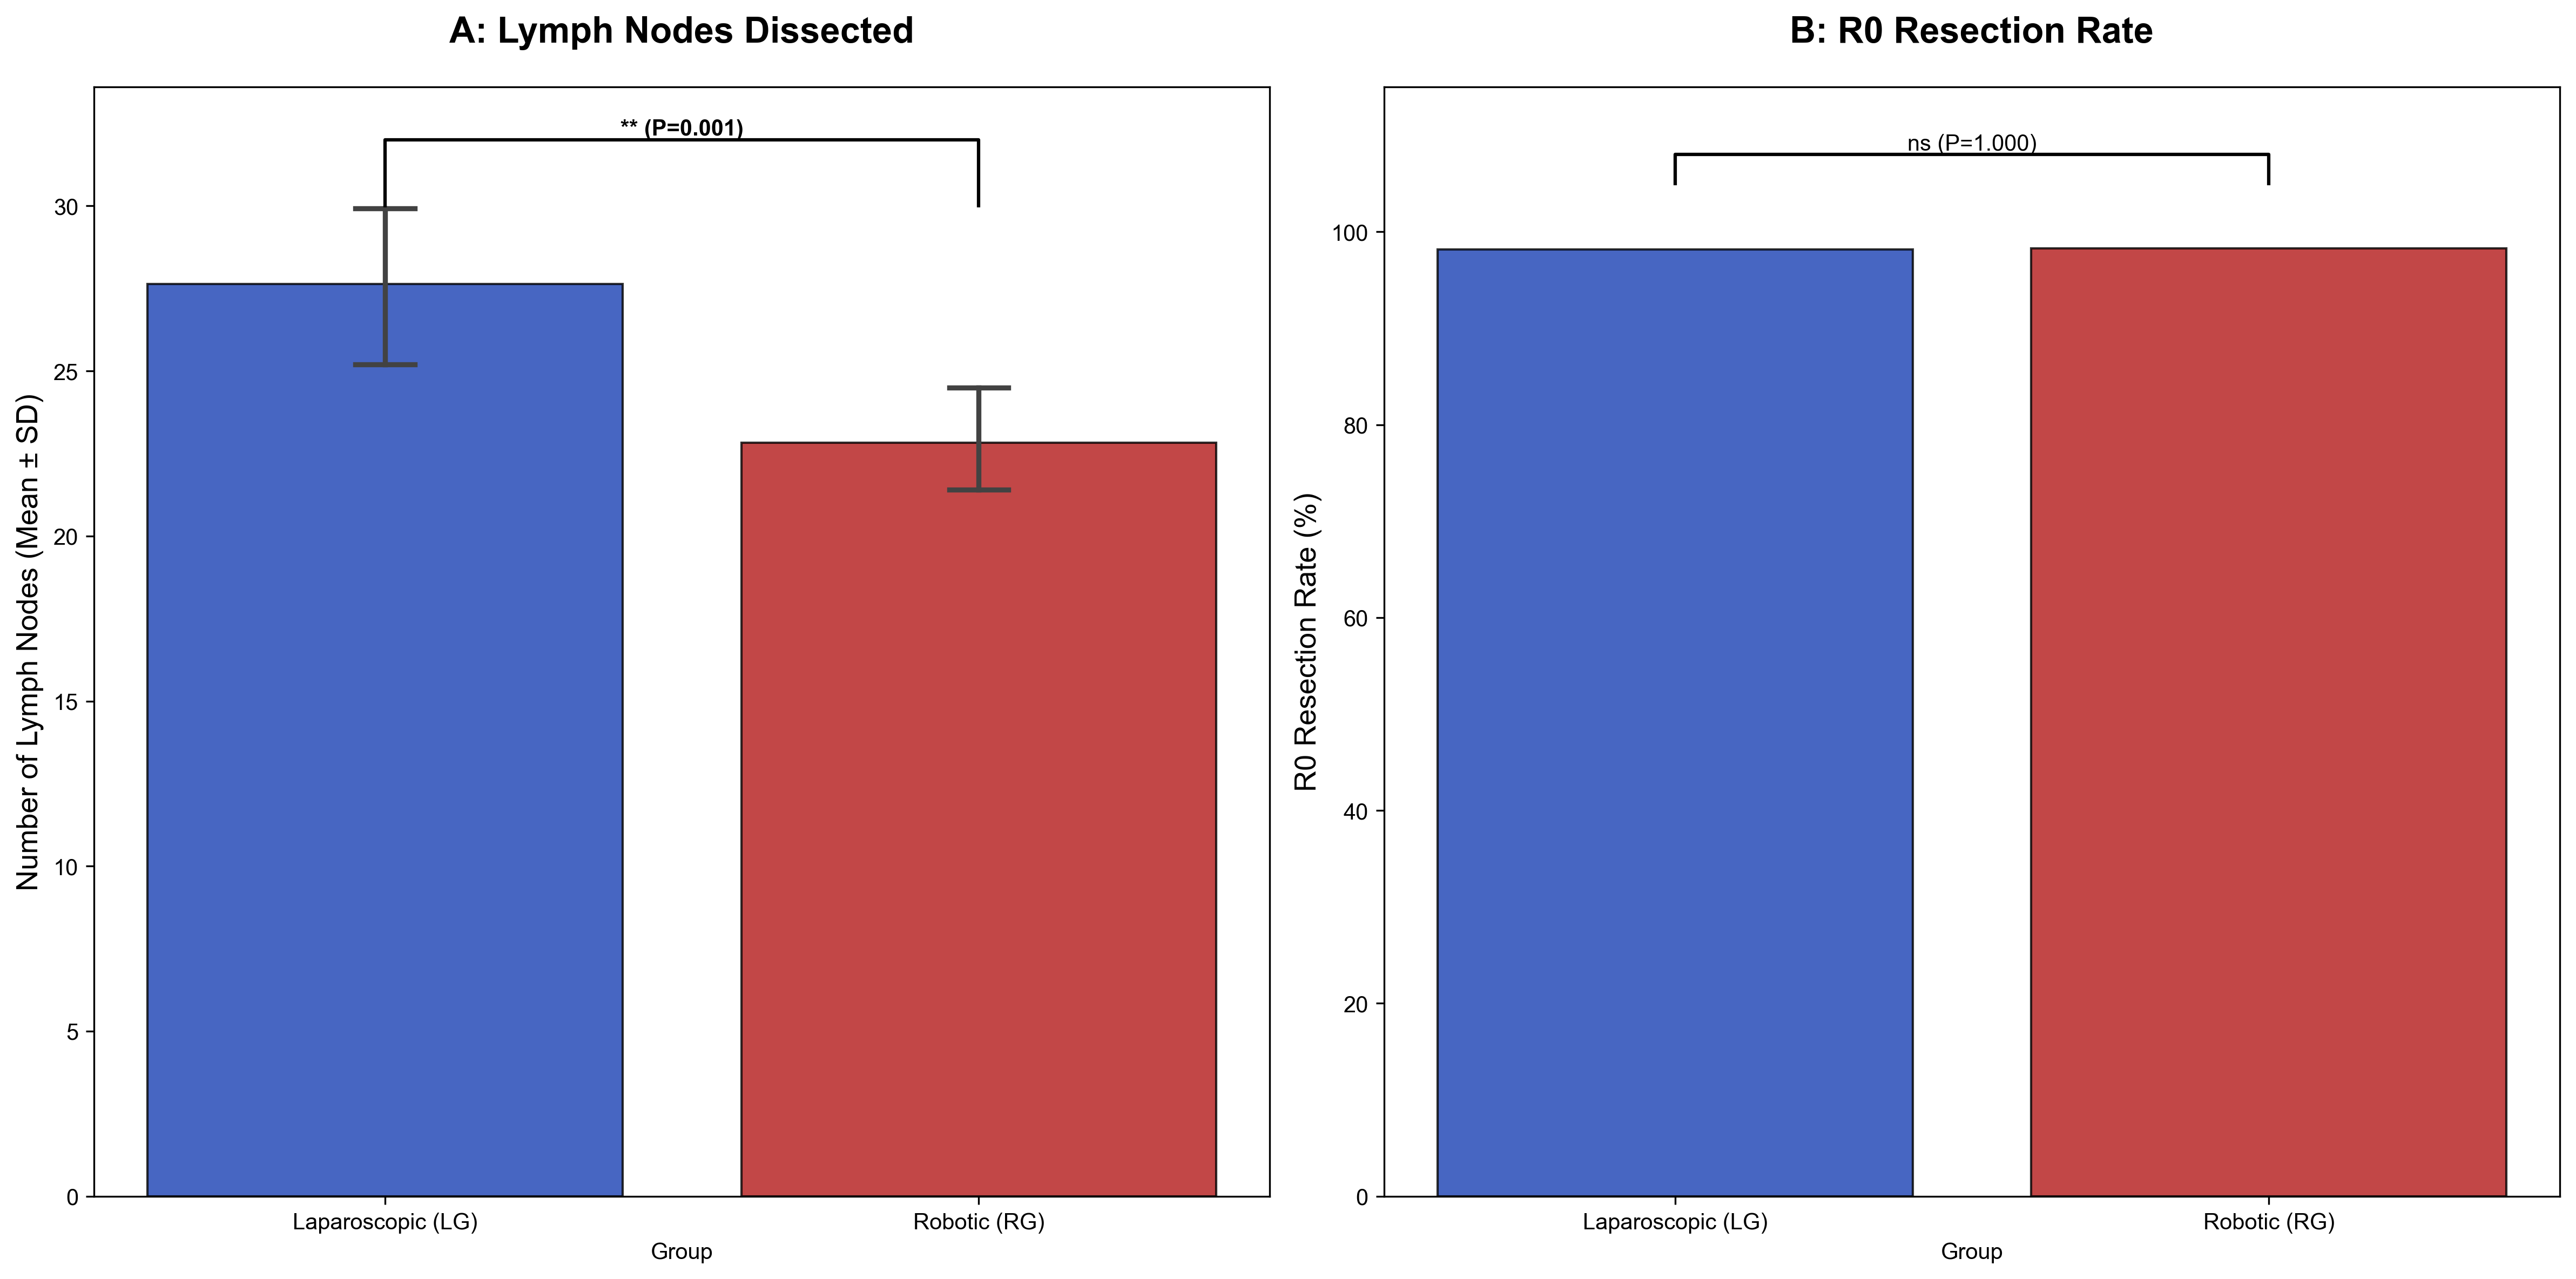

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. 加载并合并数据

df = pd.concat([pd.read_excel(f) for f in file_names], ignore_index=True)
df['Group'] = df['Operation1开腹2腔镜3机器人'].map({3: 'Robotic (RG)', 2: 'Laparoscopic (LG)'})

# 2. 数据清洗
df['LymphNodes'] = pd.to_numeric(df['淋巴结清扫数目'], errors='coerce')
df['R0_Status'] = (pd.to_numeric(df['切缘1R0，2R1，3R2'], errors='coerce') == 1).astype(int)
plot_df = df.dropna(subset=['LymphNodes', 'R0_Status'])

# 3. 开始绘图 (1x2 布局)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), dpi=300)
plt.rcParams['font.family'] = 'Arial'

# --- A图：淋巴结清扫数目 (均数±标准差) ---
sns.barplot(data=plot_df, x='Group', y='LymphNodes', ax=ax1, 
            palette={'Robotic (RG)': '#CC0000', 'Laparoscopic (LG)': '#0033CC'}, 
            capsize=.1, edgecolor='black', alpha=0.8)
ax1.set_title('A: Lymph Nodes Dissected', fontsize=16, fontweight='bold', pad=20)
ax1.set_ylabel('Number of Lymph Nodes (Mean ± SD)', fontsize=13)
# 添加显著性标注 (**)
ax1.plot([0, 0, 1, 1], [30, 32, 32, 30], lw=1.5, c='black')
ax1.text(0.5, 32, '** (P=0.001)', ha='center', va='bottom', fontweight='bold')

# --- B图：R0切除率 ---
r0_rate = plot_df.groupby('Group')['R0_Status'].mean() * 100
sns.barplot(x=r0_rate.index, y=r0_rate.values, ax=ax2, 
            palette={'Robotic (RG)': '#CC0000', 'Laparoscopic (LG)': '#0033CC'}, 
            edgecolor='black', alpha=0.8)
ax2.set_title('B: R0 Resection Rate', fontsize=16, fontweight='bold', pad=20)
ax2.set_ylabel('R0 Resection Rate (%)', fontsize=13)
ax2.set_ylim(0, 115)
# 添加显著性标注 (ns)
ax2.plot([0, 0, 1, 1], [105, 108, 108, 105], lw=1.5, c='black')
ax2.text(0.5, 108, 'ns (P=1.000)', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('Lymph_Node_and_R0_Comparison.png')
plt.show()

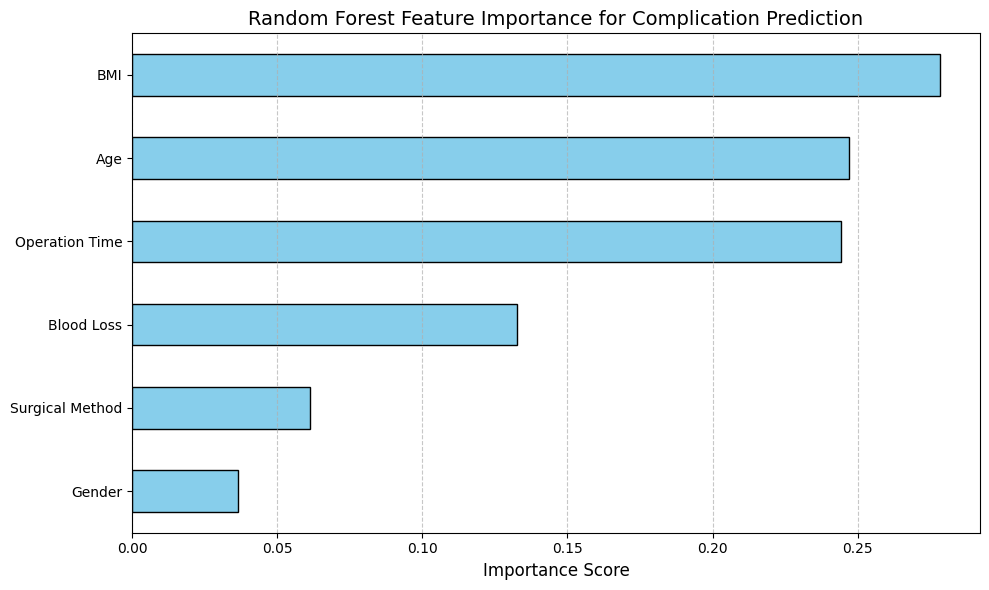

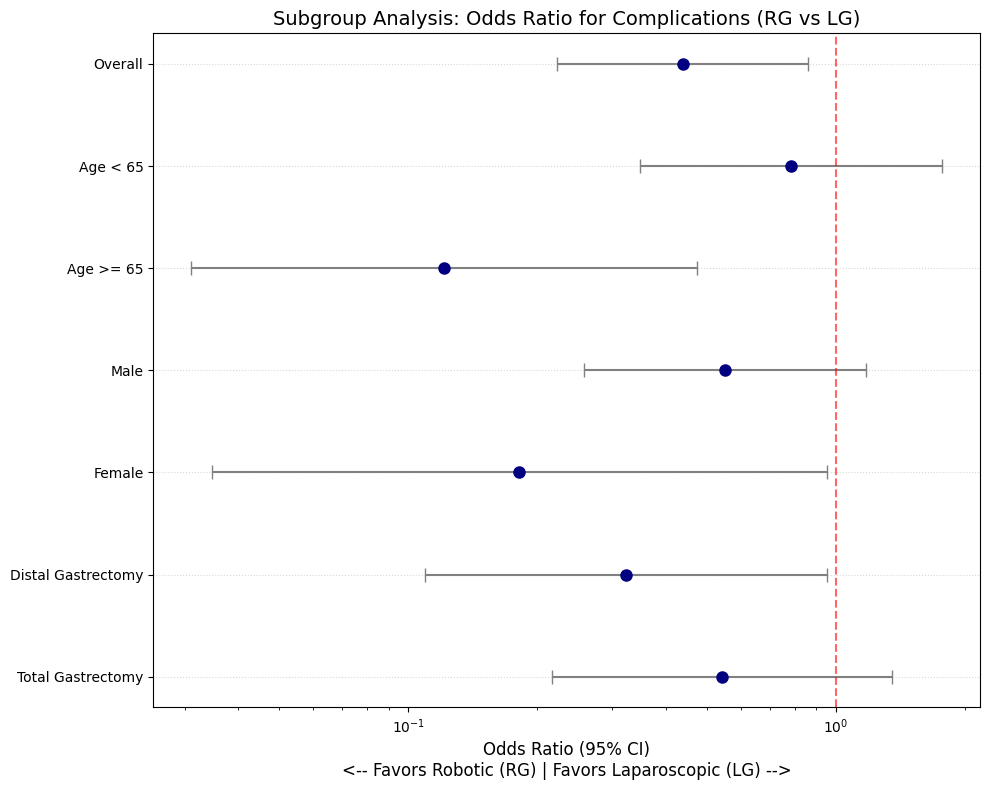

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier



# 2. 特征工程与清洗
df['Surgery_Method'] = df['Operation1开腹2腔镜3机器人'].map({2: 0, 3: 1}) # 0:LG, 1:RG
comp_cols = ['腹腔感染1是0否', '腹腔出血1是0否', '切口感染1是0否', '肺部感染1是0否', '肠梗阻1是0否', '胃潴留1是0否']
for col in comp_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
df['Any_Complication'] = (df[comp_cols].sum(axis=1) > 0).astype(int)

# 选择模型特征
features = ['Surgery_Method', '手术操作时间min', '术中出血量ml', 'Age', 'BMI', 'Gender1男2女']
df_model = df.dropna(subset=features + ['Any_Complication']).copy()
X = df_model[features].copy()
X['Gender1男2女'] = X['Gender1男2女'].map({1: 0, 2: 1}) # 0:男, 1:女
y = df_model['Any_Complication']

# ==========================================
# 3. 绘制随机森林特征重要性图
# ==========================================
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X, y)

# 提取并排序重要性
feature_display_names = ['Surgical Method', 'Operation Time', 'Blood Loss', 'Age', 'BMI', 'Gender']
importances = pd.Series(rf.feature_importances_, index=feature_display_names).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='skyblue', edgecolor='black')
plt.title('Random Forest Feature Importance for Complication Prediction', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=300)

# ==========================================
# 4. 绘制探索性亚组分析森林图 (Odds Ratio)
# ==========================================
def calculate_or_ci(subset):
    """计算机器人组 vs 腹腔镜组的 OR 和 95% CI"""
    rg = subset[subset['Surgery_Method'] == 1]
    lg = subset[subset['Surgery_Method'] == 0]
    a = rg['Any_Complication'].sum()  # RG 有并发症
    b = len(rg) - a                   # RG 无并发症
    c = lg['Any_Complication'].sum()  # LG 有并发症
    d = len(lg) - c                   # LG 无并发症
    
    # 修正：防止分母为0
    if 0 in [a, b, c, d]: a, b, c, d = a+0.5, b+0.5, c+0.5, d+0.5
    
    or_val = (a * d) / (b * c)
    se = np.sqrt(1/a + 1/b + 1/c + 1/d)
    ci_low, ci_high = np.exp(np.log(or_val) - 1.96 * se), np.exp(np.log(or_val) + 1.96 * se)
    return or_val, ci_low, ci_high

# 运行各亚组分析
sub_results = []
sub_defs = [
    ('Overall', df_model),
    ('Age < 65', df_model[df_model['Age'] < 65]),
    ('Age >= 65', df_model[df_model['Age'] >= 65]),
    ('Male', df_model[df_model['Gender1男2女'] == 1]),
    ('Female', df_model[df_model['Gender1男2女'] == 2]),
    ('Distal Gastrectomy', df_model[df_model['Excision1远端胃2全胃'] == 1]),
    ('Total Gastrectomy', df_model[df_model['Excision1远端胃2全胃'] == 2])
]

for name, subset in sub_defs:
    if len(subset) > 0:
        val, low, high = calculate_or_ci(subset)
        sub_results.append({'Subgroup': name, 'OR': val, 'Low': low, 'High': high})

forest_df = pd.DataFrame(sub_results)

# 开始绘制森林图
plt.figure(figsize=(10, 8))
y_pos = np.arange(len(forest_df))
plt.errorbar(forest_df['OR'], y_pos, xerr=[forest_df['OR']-forest_df['Low'], forest_df['High']-forest_df['OR']], 
             fmt='o', color='navy', ecolor='gray', capsize=5, markersize=8)
plt.axvline(x=1, color='red', linestyle='--', alpha=0.6) # 无差异线
plt.yticks(y_pos, forest_df['Subgroup'])
plt.gca().invert_yaxis() # 习惯上 Overall 放在最上面
plt.xscale('log') # OR 通常用对数轴展示
plt.title('Subgroup Analysis: Odds Ratio for Complications (RG vs LG)', fontsize=14)
plt.xlabel('Odds Ratio (95% CI)\n<-- Favors Robotic (RG) | Favors Laparoscopic (LG) -->', fontsize=12)
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig('subgroup_forest_plot.png', dpi=300)

plt.show()

Optimization terminated successfully.
         Current function value: 0.663349
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:          SurgeryMethod   No. Observations:                  275
Model:                          Logit   Df Residuals:                      270
Method:                           MLE   Df Model:                            4
Date:                Fri, 06 Feb 2026   Pseudo R-squ.:                 0.03029
Time:                        19:36:02   Log-Likelihood:                -182.42
converged:                       True   LL-Null:                       -188.12
Covariance Type:            nonrobust   LLR p-value:                   0.02246
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.0566      1.211     -2.524      0.012      -5.430      -0.683
Age            0.0059      0.

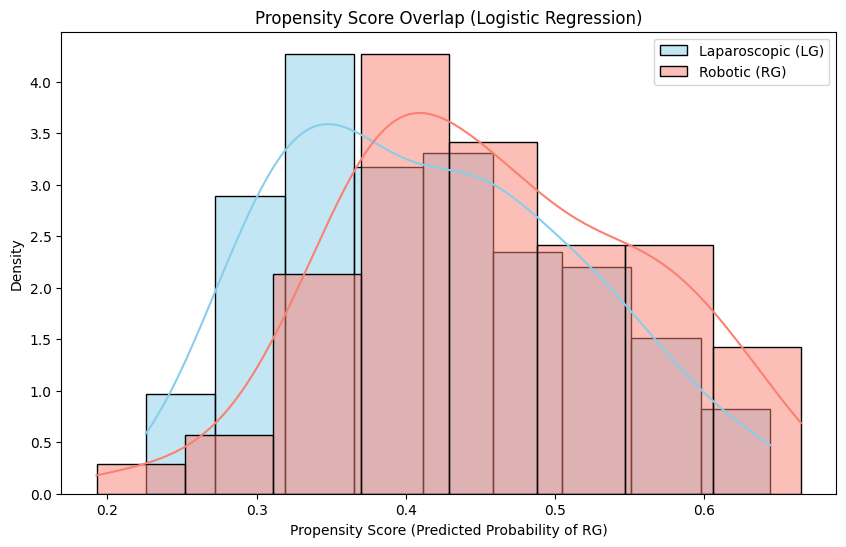

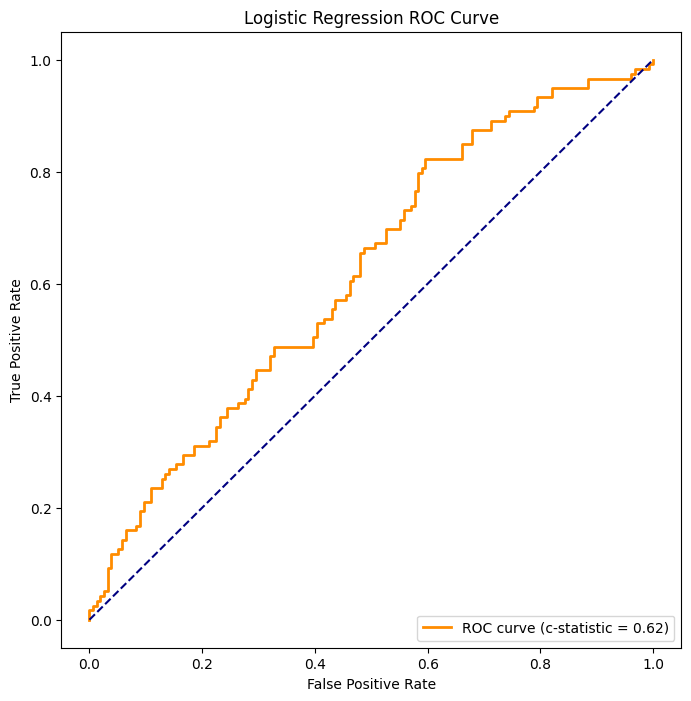

In [3]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# 1. 整合四份原始数据
file_names = [
    r"C:\Users\lenovo\Desktop\接单\机器学习模型\腹腔镜全胃切除数据.xlsx",
    r"C:\Users\lenovo\Desktop\接单\机器学习模型\腹腔镜远端胃切除数据.xlsx",
    r"C:\Users\lenovo\Desktop\接单\机器学习模型\机器人全胃切除数据.xlsx",
    r"C:\Users\lenovo\Desktop\接单\机器学习模型\机器人远端胃切除数据.xlsx"
]
dfs = [pd.read_excel(f) for f in file_names]
data = pd.concat(dfs, ignore_index=True)

# 2. 数据清洗与变量转换
# 手术方式 (SurgeryMethod): 0-腹腔镜, 1-机器人
data['SurgeryMethod'] = data['Operation1开腹2腔镜3机器人'].map({2: 0, 3: 1})
# 性别 (Gender): 0-男, 1-女
data['Gender'] = data['Gender1男2女'].map({1: 0, 2: 1})
# TNM分期转换 (根据数据编码 1-7 映射)
data['TNM_Score'] = pd.to_numeric(data['TNM'], errors='coerce')

# 提取论文要求的协变量: 年龄、性别、BMI、TNM分期
df_lr = data[['SurgeryMethod', 'Age', 'Gender', 'BMI', 'TNM_Score']].dropna()

# 3. 拟合 Logistic 回归模型
X = sm.add_constant(df_lr[['Age', 'Gender', 'BMI', 'TNM_Score']])
y = df_lr['SurgeryMethod']
model = sm.Logit(y, X)
result = model.fit()

# 计算预测概率（倾向性评分）
df_lr['Propensity_Score'] = result.predict(X)

# 4. 可视化
# A. 倾向性评分分布图 (Figure 1A 风格)
plt.figure(figsize=(10, 6))
sns.histplot(data=df_lr[df_lr['SurgeryMethod'] == 0], x='Propensity_Score', color='skyblue', label='Laparoscopic (LG)', kde=True, stat="density", alpha=0.5)
sns.histplot(data=df_lr[df_lr['SurgeryMethod'] == 1], x='Propensity_Score', color='salmon', label='Robotic (RG)', kde=True, stat="density", alpha=0.5)
plt.title('Propensity Score Overlap (Logistic Regression)')
plt.xlabel('Propensity Score (Predicted Probability of RG)')
plt.ylabel('Density')
plt.legend()
plt.savefig('propensity_score_distribution.png')

# B. ROC 曲线 (计算 C-statistic)
fpr, tpr, _ = roc_curve(y, df_lr['Propensity_Score'])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (c-statistic = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression ROC Curve')
plt.legend(loc="lower right")
plt.savefig('logistic_roc_curve.png')

print(result.summary())

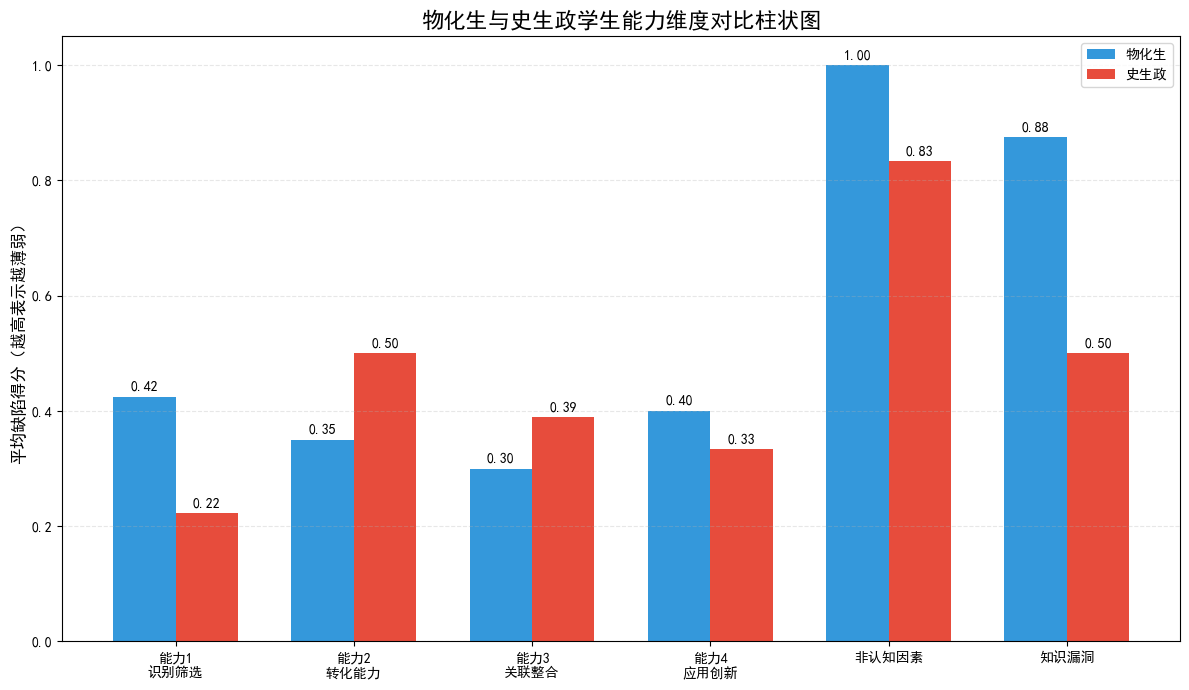

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 设置中文显示（Windows 环境常用黑体）
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 1. 读取 Excel 文件（确保文件在代码同级目录下）
file_path = r"C:\Users\lenovo\Downloads\生物学信息获取能力诊断数据汇总.xlsx"
df_scores = pd.read_excel(file_path, sheet_name='能力维度评分')

# 2. 定义需要对比的维度
dimensions = ['能力1_识别筛选', '能力2_转化能力', '能力3_关联整合', '能力4_应用创新', '非认知因素', '知识漏洞']

# 3. 按学科组合计算平均得分
group_means = df_scores.groupby('参考学科组合')[dimensions].mean()

# 4. 绘图：分组柱状图
x = np.arange(len(dimensions))  # 维度位置
width = 0.35  # 柱子宽度

fig, ax = plt.subplots(figsize=(12, 7))

# 绘制物化生组（蓝色）
rects1 = ax.bar(x - width/2, group_means.loc['物化生'], width, label='物化生', color='#3498db')
# 绘制史生政组（红色）
rects2 = ax.bar(x + width/2, group_means.loc['史生政'], width, label='史生政', color='#e74c3c')

# 添加标签、标题和样式
ax.set_ylabel('平均缺陷得分（越高表示越薄弱）', fontsize=12)
ax.set_title('物化生与史生政学生能力维度对比柱状图', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([d.replace('_', '\n') for d in dimensions]) # 换行显示标签
ax.legend()

# 在柱子上方自动添加数值标注
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), 
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

# 保存并显示图片
plt.savefig('subject_comparison_bar_chart.png', dpi=300)
plt.show()

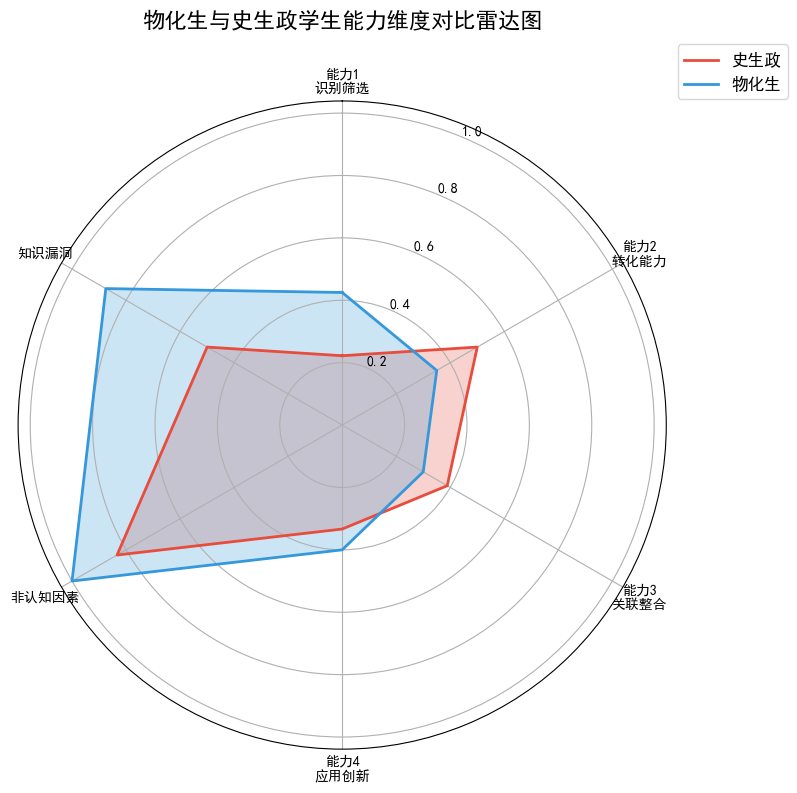

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 设置中文显示（Windows系统常用黑体）
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False



# 3. 准备维度数据
dimensions = ['能力1_识别筛选', '能力2_转化能力', '能力3_关联整合', '能力4_应用创新', '非认知因素', '知识漏洞']
labels = [d.replace('_', '\n') for d in dimensions] # 标签换行美化

# 4. 按学科组合计算平均分
group_means = df_scores.groupby('参考学科组合')[dimensions].mean()

# 5. 雷达图参数设置
num_vars = len(dimensions)
# 计算角度（平分360度）
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # 闭合圆圈

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# 6. 开始绘制各组数据
colors = {'物化生': '#3498db', '史生政': '#e74c3c'} # 蓝色和红色对比

for group_name in group_means.index:
    values = group_means.loc[group_name].tolist()
    values += values[:1]  # 数据首尾相连
    ax.plot(angles, values, linewidth=2, label=group_name, color=colors.get(group_name))
    ax.fill(angles, values, alpha=0.25, color=colors.get(group_name))

# 7. 美化图表设置
ax.set_theta_offset(np.pi / 2)  # 起始点设在正上方
ax.set_theta_direction(-1)      # 顺时针方向
ax.set_thetagrids(np.degrees(angles[:-1]), labels) # 设置各轴标签

# 设置标题和图例
ax.set_title('物化生与史生政学生能力维度对比雷达图', fontsize=16, fontweight='bold', y=1.1)
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1), fontsize=12)

plt.tight_layout()
plt.savefig('subject_comparison_radar_chart.png', dpi=300)
plt.show()

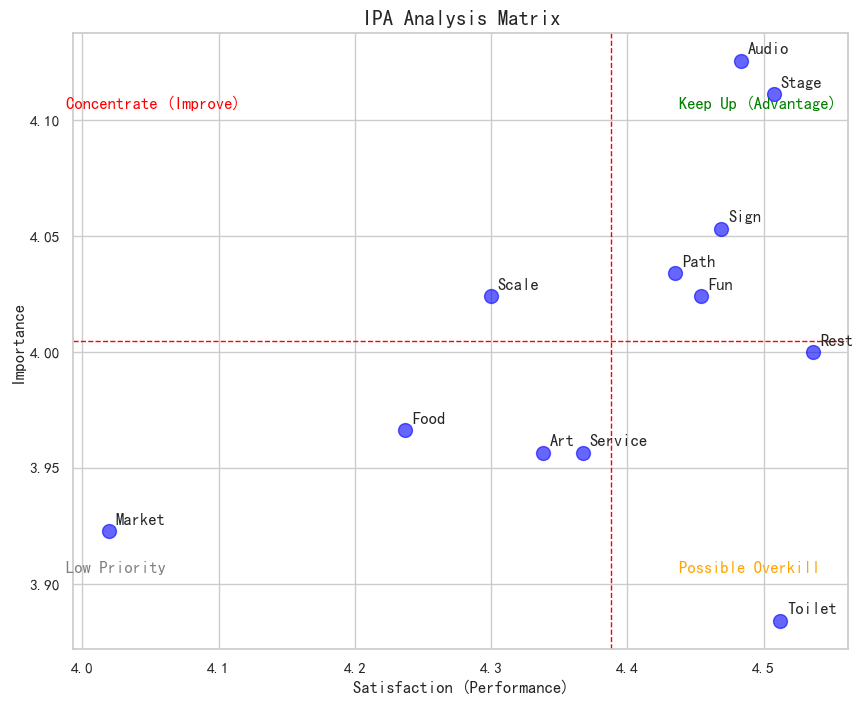

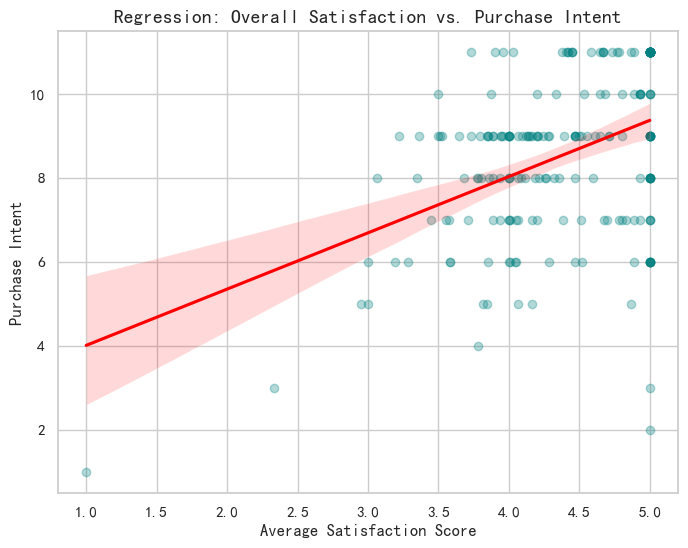

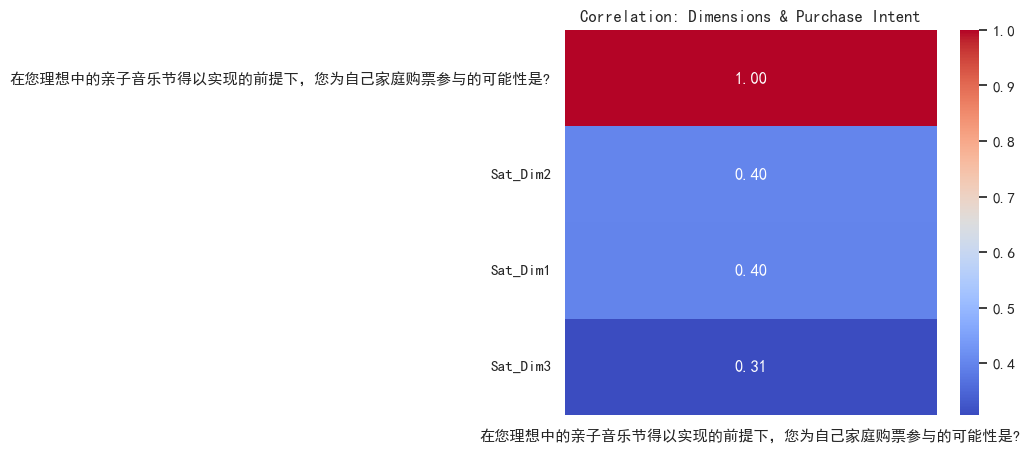

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# 1. 数据加载与预处理
# 读取原始数据
df = pd.read_excel(r"C:\Users\lenovo\Desktop\接单\问卷分析\336541420_按序号_上海国际儿童亲子音乐节空间体验调查问卷_207_207.xlsx")

# 定义列索引：满意度(37-48列)，重要性(49-60列)，因变量(购票意愿)
all_cols = df.columns.tolist()
sat_names = all_cols[37:49] 
imp_names = all_cols[49:61]
dep_var = '在您理想中的亲子音乐节得以实现的前提下，您为自己家庭购票参与的可能性是?'

# 清洗数据：转为数值型并剔除缺失值
data = df[sat_names + imp_names + [dep_var]].copy()
data = data.apply(pd.to_numeric, errors='coerce').dropna()

# 维度划分（参考论文评价体系）
# 维度1：核心演出与互动；维度2：基础设施与动线；维度3：服务与配套
data['Sat_Dim1'] = data[sat_names[0:5]].mean(axis=1)
data['Sat_Dim2'] = data[sat_names[5:9]].mean(axis=1)
data['Sat_Dim3'] = data[sat_names[9:12]].mean(axis=1)

# --- 绘图设置 ---
plt.rcParams['font.sans-serif'] = ['DejaVu Sans'] # 若环境支持中文可改为 'SimHei'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid")

# 2. 图表一：IPA 分析矩阵 (Importance-Performance Analysis)
labels = ['Stage', 'Audio', 'Fun', 'Art', 'Scale', 'Sign', 'Path', 'Rest', 'Toilet', 'Service', 'Food', 'Market']
sat_means = [data[col].mean() for col in sat_names]
imp_means = [data[col].mean() for col in imp_names]
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(10, 8))
plt.scatter(sat_means, imp_means, c='blue', s=100, alpha=0.6)

# 绘制十字交叉线（均值线）
m_sat, m_imp = np.mean(sat_means), np.mean(imp_means)
plt.axvline(m_sat, color='red', linestyle='--', linewidth=1)
plt.axhline(m_imp, color='red', linestyle='--', linewidth=1)

# 打标签
for i, label in enumerate(labels):
    plt.annotate(label, (sat_means[i], imp_means[i]), xytext=(5, 5), textcoords='offset points')

plt.title('IPA Analysis Matrix', fontsize=15)
plt.xlabel('Satisfaction (Performance)', fontsize=12)
plt.ylabel('Importance', fontsize=12)

# 添加象限说明
plt.text(m_sat + 0.05, m_imp + 0.1, 'Keep Up (Advantage)', color='green', weight='bold')
plt.text(m_sat - 0.4, m_imp + 0.1, 'Concentrate (Improve)', color='red', weight='bold')
plt.text(m_sat - 0.4, m_imp - 0.1, 'Low Priority', color='gray', weight='bold')
plt.text(m_sat + 0.05, m_imp - 0.1, 'Possible Overkill', color='orange', weight='bold')
plt.savefig('ipa_analysis.png')
plt.show()


# 3. 图表二：回归分析 (满意度与购票意愿)
data['Total_Sat'] = data[['Sat_Dim1', 'Sat_Dim2', 'Sat_Dim3']].mean(axis=1)

plt.figure(figsize=(8, 6))
sns.regplot(x='Total_Sat', y=dep_var, data=data, 
            color='teal', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Regression: Overall Satisfaction vs. Purchase Intent', fontsize=14)
plt.xlabel('Average Satisfaction Score', fontsize=12)
plt.ylabel('Purchase Intent', fontsize=12)
plt.savefig('regression_analysis.png')
plt.show()


# 4. 图表三：相关性热力图
corr_sat = data[['Sat_Dim1', 'Sat_Dim2', 'Sat_Dim3', dep_var]].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_sat[[dep_var]].sort_values(by=dep_var, ascending=False), 
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation: Dimensions & Purchase Intent')
plt.savefig('correlation_heatmap.png')
plt.show()

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# 1. 环境与中文字体配置 (针对常见环境)
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans'] # 优先使用黑体
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font='SimHei')

# 2. 加载数据 (使用沙盒环境中的 CSV 文件名)
df = pd.read_excel(r"C:\Users\lenovo\Desktop\接单\问卷分析\336541420_按序号_上海国际儿童亲子音乐节空间体验调查问卷_207_207.xlsx")

# 3. 变量定义
# 满意度(37-48列)，重要性(49-60列)
all_cols = df.columns.tolist()
sat_names = all_cols[37:49] 
imp_names = all_cols[49:61]
dep_var = '在您理想中的亲子音乐节得以实现的前提下，您为自己家庭购票参与的可能性是?'

# 清洗数据：转为数值型并剔除缺失值
data = df[sat_names + imp_names + [dep_var]].copy()
data = data.apply(pd.to_numeric, errors='coerce').dropna()

# 4. 维度划分 (参考论文 p35 表 2-6 的逻辑)
# 维度1 (核心体验): a, b, c1, c2, c3
# 维度2 (设施规划): d1, d2, e, f
# 维度3 (服务配套): g, h1, h2
dimensions = {
    'Core_Exp': [0, 1, 2, 3, 4],
    'Facility': [5, 6, 7, 8],
    'Support': [9, 10, 11]
}

for dim, idxs in dimensions.items():
    data[f'Sat_{dim}'] = data[[sat_names[i] for i in idxs]].mean(axis=1)
    data[f'Imp_{dim}'] = data[[imp_names[i] for i in idxs]].mean(axis=1)

data['Total_Sat'] = data[sat_names].mean(axis=1)
data['Total_Imp'] = data[imp_names].mean(axis=1)

# --- 绘图函数定义 ---
def plot_corr(cols, target, title, filename):
    plt.figure(figsize=(6, 5))
    corr = data[cols + [target]].corr()
    sns.heatmap(corr[[target]].sort_values(by=target, ascending=False), 
                annot=True, cmap='RdBu_r', center=0, fmt=".2f")
    plt.title(title)
    plt.savefig(filename, bbox_inches='tight')
    plt.close()

def plot_reg(x_col, y_col, title, filename, color):
    plt.figure(figsize=(8, 6))
    sns.regplot(x=x_col, y=y_col, data=data, color=color, 
                scatter_kws={'alpha':0.3}, line_kws={'color':'red', 'label':'Regression Line'})
    plt.title(title)
    plt.xlabel('Average Score')
    plt.ylabel('Purchase Intent')
    plt.savefig(filename, bbox_inches='tight')
    plt.close()

# 5. 执行分析并保存 5 张图表
# A. 满意度相关性与回归
plot_corr(['Sat_Core_Exp', 'Sat_Facility', 'Sat_Support'], dep_var, 'Satisfaction Correlation', '1_Sat_Corr.png')
plot_reg('Total_Sat', dep_var, 'Regression: Overall Satisfaction vs Intent', '2_Sat_Reg.png', 'teal')

# B. 重要性相关性与回归
plot_corr(['Imp_Core_Exp', 'Imp_Facility', 'Imp_Support'], dep_var, 'Importance Correlation', '3_Imp_Corr.png')
plot_reg('Total_Imp', dep_var, 'Regression: Overall Importance vs Intent', '4_Imp_Reg.png', 'orange')

# C. IPA 分析矩阵
labels = ['Stage', 'Audio', 'Fun', 'Art', 'Scale', 'Sign', 'Path', 'Rest', 'Toilet', 'Service', 'Food', 'Market']
sat_means = [data[col].mean() for col in sat_names]
imp_means = [data[col].mean() for col in imp_names]

plt.figure(figsize=(10, 8))
m_sat, m_imp = np.mean(sat_means), np.mean(imp_means)
plt.scatter(sat_means, imp_means, c='blue', s=100, alpha=0.6)
plt.axvline(m_sat, color='red', linestyle='--', alpha=0.5)
plt.axhline(m_imp, color='red', linestyle='--', alpha=0.5)

for i, label in enumerate(labels):
    plt.annotate(label, (sat_means[i], imp_means[i]), xytext=(5, 5), textcoords='offset points')

plt.title('IPA Matrix: Importance vs Performance')
plt.xlabel('Satisfaction (Performance)')
plt.ylabel('Importance')
plt.text(m_sat+0.05, m_imp+0.1, '优势区 (Keep Up)', color='green', fontweight='bold')
plt.text(m_sat-0.4, m_imp+0.1, '改进区 (Improve)', color='red', fontweight='bold')
plt.text(m_sat-0.4, m_imp-0.1, '机会区 (Low Priority)', color='gray')
plt.text(m_sat+0.05, m_imp-0.1, '维持区 (Overkill)', color='orange')
plt.savefig('5_IPA_Analysis.png', bbox_inches='tight')
plt.close()

print("分析完成，生成图表：1_Sat_Corr.png, 2_Sat_Reg.png, 3_Imp_Corr.png, 4_Imp_Reg.png, 5_IPA_Analysis.png")

分析完成，生成图表：1_Sat_Corr.png, 2_Sat_Reg.png, 3_Imp_Corr.png, 4_Imp_Reg.png, 5_IPA_Analysis.png
